## Cldn4 Article Figs
March 10th 2026
by e_bruli

In [1]:
#If not loaded already:
#!pip install scanpy
#!pip install pandas
#!pip install openpyxl
#!pip install matplotlib
#!pip install pydeseq2
import scanpy as sc
import pandas as pd
import random
import numpy as np
import matplotlib as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gc 
import ctypes
gc.collect()
libc = ctypes.CDLL("libc.so.6") # clearing cache 
libc.malloc_trim(0)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx

1

In [6]:
#LuCa dataset
adata = sc.read_h5ad('/home/biolab/Projects/DesCARTes_wd/data/202603_luca.h5ad')
adata

AnnData object with n_obs × n_vars = 1283972 × 17764
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'm

In [7]:
#change ensmble id to gene name:
adata.var_names = adata.var['feature_name']
adata.var_names_make_unique()

# Verify
print("CLDN4" in adata.var_names)  # should print True

True


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'A2ML1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


In [8]:
adata.var

,is_highly_variable,mito,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
feature_name,,,,,,,,,,,,
A1BG,True,False,86866,2.527138,90.681054,2355657.0,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
A1BG-AS1,True,False,12257,0.369194,98.685074,344142.0,False,A1BG-AS1,NCBITaxon:9606,gene,1667,lncRNA
A2M,True,False,122241,22.579874,86.886039,21047694.0,False,A2M,NCBITaxon:9606,gene,590,protein_coding
A2M-AS1,False,False,8827,0.172223,99.053043,160537.0,False,A2M-AS1,NCBITaxon:9606,gene,1809,lncRNA
A2ML1,True,False,5096,0.038011,99.453303,35432.0,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,False,False,43291,0.442399,95.355760,412380.0,False,ZXDC,NCBITaxon:9606,gene,3006,protein_coding
ZYG11A,False,False,3517,0.009742,99.622698,9081.0,False,ZYG11A,NCBITaxon:9606,gene,4193,protein_coding
ZYG11B,False,False,71512,0.275276,92.328224,256597.0,False,ZYG11B,NCBITaxon:9606,gene,5218,protein_coding


In [2]:
!pwd

/mnt/ssd1/Projects/DesCARTes_wd/notebooks


In [ ]:
!pwd

/mnt/ssd1/Projects/DesCARTes_wd/notebooks


In [ ]:
## My Original code

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    To create an an data with pseudo-bulk gene expression profiles for the samples and cell_types given.
    The function also carries metadata columns from the obs. metacols: as a list of col names.
    This is how to use:
        ps_adata = make_pseudobulk(hlca, sample_colname = 'sample', cell_type_colname = 'cell_type', metacols= ['patient', 'disease', 'tissue', 'study', 'sex'])
    '''
    ps_list = []
    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]
            
            adata_rep = sc.AnnData(X = adata_sub_ct.X.sum(axis = 0),
                                   var = adata_sub_ct.var[[]])
            samp_name=adata_sub.obs[sample_colname].iloc[0]
            cell= adata_sub_ct.obs[cell_type_colname].iloc[0]
            adata_rep.obs_names = [f"{samp_name}{cell}"]
            adata_rep.obs[cell_type_colname] = adata_sub_ct.obs[cell_type_colname].iloc[0]
            adata_rep.obs[metacols] = adata_sub_ct.obs[metacols].iloc[0]
            ps_list.append(adata_rep)

    ps_adata = sc.concat(ps_list)
    
    return ps_adata



def savePBdata(adata, filename):
    #save the count matrix as df
    counts = adata.DataFrame(adata.X, columns = adata.var_names)
    counts = counts.astype(int, errors='ignore')
    #To get rid off all the 0s in count matrix (to prevent problems)
    counts=counts+1
    #save the obs as colData
    

 #Create a pseudo-bulk of LuCa-extended.

ps_adata_luca = make_pseudobulk(adata, sample_colname = 'sample', cell_type_colname = 'cell_type', metacols= ['donor_id', 'disease', 'tissue', 'study', 'sex', 'age', 'uicc_stage', 'tumor_stage']) 




#save pseudobulk object
#convert numpy matrix to numpy array:
ps_adata_luca.X = np.asarray(ps_adata_luca)
ps_adata_luca.write_h5ad('luca_ps_profile.h5ad')

/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma

KeyboardInterrupt: 

CLDN4 in adata.var_names: True
CLDN4 in adata.raw.var_names: True
Pipeline 1 — 1,014,841 cells, 434 samples
origin
tumor_primary       585138
normal_adjacent     325538
tumor_metastasis     71272
normal               32893
Name: count, dtype: int64


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk P1 shape: (7381, 17764)


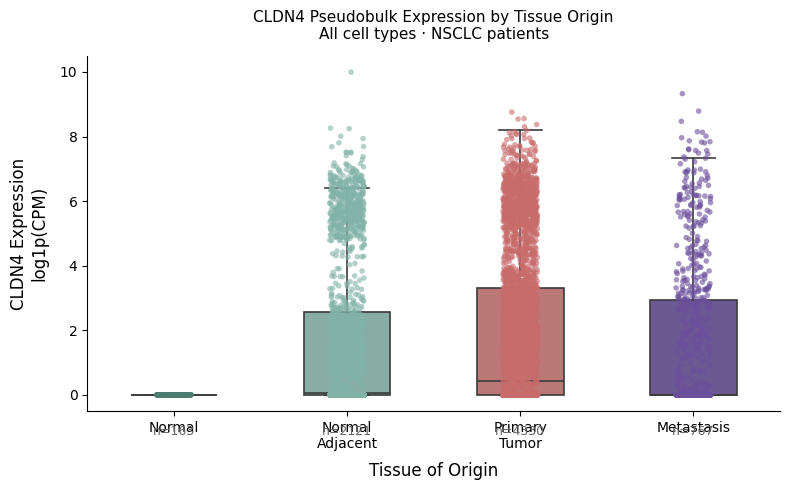

Saved: cldn4_by_origin.pdf / .png


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse


import os

# ── Define output directory ────────────────────────────────────────
OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs"  # change this to your desired path
os.makedirs(OUT_DIR, exist_ok=True) # creates the folder if it doesn't exist

# ══════════════════════════════════════════════════════════════════════════════
# PSEUDOBULK FUNCTION cleaned up with Claude
# ══════════════════════════════════════════════════════════════════════════════

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    Creates pseudobulk AnnData by summing RAW counts per sample x cell_type.
    Uses adata.raw.X (raw counts) so downstream CPM + log1p normalization is valid.
    Each resulting row = one sample x cell_type combination.
    '''
    assert adata.raw is not None, \
        "adata.raw is None — raw counts not stored. Cannot use Option A."

    # Build a var DataFrame from raw (raw may contain more genes than adata.X)
    raw_var = pd.DataFrame(index=adata.raw.var_names)

    ps_list = []
    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]

            # Use raw counts — correct for pseudobulk aggregation
            X_sum = adata_sub_ct.raw.X.sum(axis=0)
            if issparse(X_sum):
                X_sum = X_sum.toarray()

            adata_rep = sc.AnnData(
                X   = X_sum,
                var = raw_var          # use raw var so gene names align
            )
            samp_name = adata_sub.obs[sample_colname].iloc[0]
            cell      = adata_sub_ct.obs[cell_type_colname].iloc[0]

            adata_rep.obs_names           = [f"{samp_name}_{cell}"]
            adata_rep.obs[cell_type_colname] = cell
            adata_rep.obs[metacols]       = adata_sub_ct.obs[metacols].iloc[0].values

            ps_list.append(adata_rep)

    return sc.concat(ps_list)


def extract_gene(ps_adata, gene):
    '''Extract a single gene's expression from pseudobulk AnnData into obs.
    Note: var_names come from adata.raw — must use gene symbols (feature_name).
    '''
    assert gene in ps_adata.var_names, \
        f"{gene} not found in var_names — check that adata.raw.var_names uses gene symbols!"
    idx  = ps_adata.var_names.get_loc(gene)
    expr = ps_adata.X[:, idx]
    if issparse(expr):
        expr = expr.toarray().flatten()
    ps_adata.obs[f"{gene}_expr"] = np.array(expr).flatten()
    return ps_adata


# ══════════════════════════════════════════════════════════════════════════════
# SHARED SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Swap var_names to gene symbols if not already done
if "CLDN4" not in adata.var_names:
    adata.var_names = adata.var["feature_name"]
    adata.var_names_make_unique()

# ++ Do the same for adata.raw ++
if "CLDN4" not in adata.raw.var_names:
    raw_adata = adata.raw.to_adata()
    raw_adata.var_names = raw_adata.var["feature_name"]
    raw_adata.var_names_make_unique()
    adata.raw = raw_adata

print("CLDN4 in adata.var_names:", "CLDN4" in adata.var_names)
print("CLDN4 in adata.raw.var_names:", "CLDN4" in adata.raw.var_names)

# Remap disease labels (COPD → NaN → excluded by masks)
disease_map = {
    "lung adenocarcinoma"          : "NSCLC",
    "squamous cell lung carcinoma" : "NSCLC",
    "non-small cell lung carcinoma": "NSCLC",
    "normal"                       : "Normal",
}
adata.obs["disease_grouped"] = adata.obs["disease"].map(disease_map)


# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 1 — ALL CELL TYPES FROM CANCER PATIENTS → PLOT BY ORIGIN
# ══════════════════════════════════════════════════════════════════════════════

# ── 1a. Subset: all cells from NSCLC patients, exclude NaN origin ─────────
mask_p1 = (
    (adata.obs["disease_grouped"] == "NSCLC") &
    (adata.obs["origin"].isin(["normal", "normal_adjacent",
                                "tumor_primary", "tumor_metastasis"]))
)
adata_p1 = adata[mask_p1].copy()
print(f"Pipeline 1 — {adata_p1.n_obs:,} cells, "
      f"{adata_p1.obs['sample'].nunique()} samples")
print(adata_p1.obs["origin"].value_counts())

# ── 1b. Pseudobulk per sample × cell_type_major ───────────────────────────
ps1 = make_pseudobulk(
    adata_p1,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "origin"]
)
print(f"\nPseudobulk P1 shape: {ps1.shape}")

# ── 1c. Normalize ─────────────────────────────────────────────────────────
sc.pp.normalize_total(ps1, target_sum=1e6)  # CPM
sc.pp.log1p(ps1)                            # log1p(CPM)

# ── 1d. Extract CLDN4 ──────────────────────────────────────────────────────
ps1 = extract_gene(ps1, "CLDN4")

# ── 1e. Plot ───────────────────────────────────────────────────────────────
origin_order  = ["normal", "normal_adjacent", "tumor_primary", "tumor_metastasis"]
origin_colors = {
    "normal"            : "#4a7c6f",
    "normal_adjacent"   : "#82b3a8",
    "tumor_primary"     : "#c86b6b",
    "tumor_metastasis"  : "#6b4f9b",
}
palette1 = [origin_colors[o] for o in origin_order]

fig1, ax1 = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data      = ps1.obs,
    x         = "origin",
    y         = "CLDN4_expr",
    order     = origin_order,
    palette   = palette1,
    width     = 0.5,
    linewidth = 1.2,
    fliersize = 0,
    ax        = ax1,
)
sns.stripplot(
    data      = ps1.obs,
    x         = "origin",
    y         = "CLDN4_expr",
    order     = origin_order,
    palette   = palette1,
    size      = 4,
    alpha     = 0.6,
    jitter    = True,
    ax        = ax1,
)

# Sample size annotations
ymin1, ymax1 = ax1.get_ylim()
for i, org in enumerate(origin_order):
    n = (ps1.obs["origin"] == org).sum()
    ax1.text(i, ymin1 - 0.04*(ymax1-ymin1),
             f"n={n}", ha="center", va="top", fontsize=9, color="#666666")

ax1.set_xticklabels(["Normal", "Normal\nAdjacent", "Primary\nTumor", "Metastasis"],
                     fontsize=10)
ax1.set_xlabel("Tissue of Origin", fontsize=12, labelpad=8)
ax1.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax1.set_title("CLDN4 Pseudobulk Expression by Tissue Origin\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_origin.pdf / .png")




Pipeline 2 — 89,242 tumor cells, 247 samples
uicc_stage
III or IV    32446
IV           18349
I            16129
III          14486
II            7832
Name: count, dtype: int64


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk P2 shape: (247, 17764)

Unique stage labels: ['III', 'I', 'II', 'IV', 'III or IV']


<Figure size 640x480 with 0 Axes>

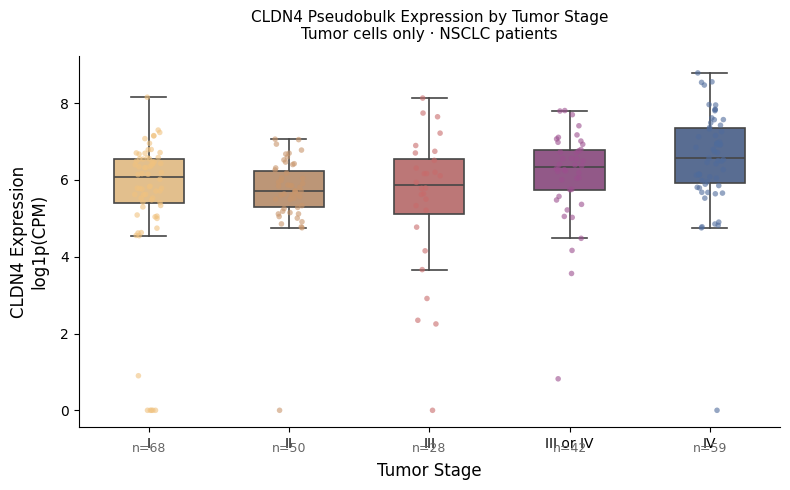

Saved: cldn4_by_stage.pdf / .png


In [ ]:
OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs"   # change this to your desired path
os.makedirs(OUT_DIR, exist_ok=True) # creates the folder if it doesn't exist

plt.tight_layout()
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 2 — TUMOR CELLS ONLY → PLOT BY TUMOR STAGE
# ══════════════════════════════════════════════════════════════════════════════

# ── 2a. Subset: Tumor cells from NSCLC patients with known stage ──────────
mask_p2 = (
    (adata.obs["disease_grouped"] == "NSCLC")              &
    (adata.obs["cell_type_major"] == "Tumor cells")        &
    (adata.obs["origin"].isin(["tumor_primary",
                                "tumor_metastasis"]))      &
    (adata.obs["uicc_stage"].notna())
)
adata_p2 = adata[mask_p2].copy()
print(f"\nPipeline 2 — {adata_p2.n_obs:,} tumor cells, "
      f"{adata_p2.obs['sample'].nunique()} samples")
print(adata_p2.obs["uicc_stage"].value_counts())

# ── 2b. Pseudobulk per sample (only Tumor cells → one row per sample) ─────
ps2 = make_pseudobulk(
    adata_p2,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "uicc_stage", "origin"]
)
print(f"\nPseudobulk P2 shape: {ps2.shape}")

# ── 2c. Normalize ─────────────────────────────────────────────────────────
sc.pp.normalize_total(ps2, target_sum=1e6)
sc.pp.log1p(ps2)

# ── 2d. Extract CLDN4 ──────────────────────────────────────────────────────
ps2 = extract_gene(ps2, "CLDN4")

# ── 2e. Order stages ───────────────────────────────────────────────────────
# !! Print unique values and adjust stage_order if labels differ !!
print("\nUnique stage labels:", ps2.obs["uicc_stage"].unique().tolist())

stage_order  = ["I", "II", "III", "III or IV", "IV"]   # adjust if needed
stage_order  = [s for s in stage_order if s in ps2.obs["uicc_stage"].values]
stage_colors = {
    "I"        : "#f0c27f",
    "II"       : "#c8956b",
    "III"      : "#c86b6b",
    "III or IV": "#9b4f8e",
    "IV"       : "#4f6b9b",
}
palette2 = [stage_colors.get(s, "#888888") for s in stage_order]

df2 = ps2.obs[["uicc_stage", "CLDN4_expr"]].copy()
df2["uicc_stage"] = pd.Categorical(
    df2["uicc_stage"], categories=stage_order, ordered=True
)
df2 = df2[df2["uicc_stage"].notna()].copy()

# ── 2f. Plot ───────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data      = df2,
    x         = "uicc_stage",
    y         = "CLDN4_expr",
    order     = stage_order,
    palette   = palette2,
    width     = 0.5,
    linewidth = 1.2,
    fliersize = 0,
    ax        = ax2,
)
sns.stripplot(
    data      = df2,
    x         = "uicc_stage",
    y         = "CLDN4_expr",
    order     = stage_order,
    palette   = palette2,
    size      = 4,
    alpha     = 0.6,
    jitter    = True,
    ax        = ax2,
)

# Sample size annotations
ymin2, ymax2 = ax2.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df2["uicc_stage"] == stage).sum()
    ax2.text(i, ymin2 - 0.04*(ymax2-ymin2),
             f"n={n}", ha="center", va="top", fontsize=9, color="#666666")

ax2.set_xlabel("Tumor Stage", fontsize=12, labelpad=8)
ax2.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax2.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nTumor cells only · NSCLC patients",
              fontsize=11, pad=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage.pdf / .png")

In [8]:
adata

AnnData object with n_obs × n_vars = 1283972 × 17764
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'm

final code for the 3 plots: (13.03.2026)

In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import issparse

# ══════════════════════════════════════════════════════════════════════════════
# OUTPUT DIRECTORY
# ══════════════════════════════════════════════════════════════════════════════

OUT_DIR = "/home/ebrukocakaya/202603_cldn4_figs/fig_2/"   # !! change this !!
os.makedirs(OUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    Creates pseudobulk AnnData by summing RAW counts per sample × cell_type.
    Uses adata.raw.X so downstream CPM + log1p normalization is valid.
    Each row = one sample × cell_type combination.
    '''
    assert adata.raw is not None, \
        "adata.raw is None — raw counts not stored!"

    raw_var = pd.DataFrame(index=adata.raw.var_names)
    ps_list = []

    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]

            X_sum = adata_sub_ct.raw.X.sum(axis=0)
            if issparse(X_sum):
                X_sum = X_sum.toarray()

            adata_rep = sc.AnnData(X=X_sum, var=raw_var)

            samp_name = adata_sub.obs[sample_colname].iloc[0]
            cell      = adata_sub_ct.obs[cell_type_colname].iloc[0]

            adata_rep.obs_names              = [f"{samp_name}_{cell}"]
            adata_rep.obs[cell_type_colname] = cell
            adata_rep.obs[metacols]          = adata_sub_ct.obs[metacols].iloc[0].values

            ps_list.append(adata_rep)

    return sc.concat(ps_list)


def extract_gene(ps_adata, gene):
    '''Extract a single gene's expression from pseudobulk AnnData into obs.'''
    assert gene in ps_adata.var_names, \
        f"{gene} not found in var_names — check adata.raw.var_names uses gene symbols!"
    idx  = ps_adata.var_names.get_loc(gene)
    expr = ps_adata.X[:, idx]
    if issparse(expr):
        expr = expr.toarray().flatten()
    ps_adata.obs[f"{gene}_expr"] = np.array(expr).flatten()
    return ps_adata


def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "ns"


def add_significance(ax, group_order, group_col, expr_col, df,
                     ref_group, ymax, step_size=0.07):
    '''
    Draws significance brackets comparing ref_group vs all other groups.
    Uses Mann-Whitney U (Wilcoxon rank-sum) test.
    '''
    ref_data = df[df[group_col] == ref_group][expr_col].dropna().values
    ref_x    = group_order.index(ref_group)
    comparisons = [g for g in group_order if g != ref_group]

    for step, comp in enumerate(comparisons):
        comp_data = df[df[group_col] == comp][expr_col].dropna().values
        _, p      = stats.mannwhitneyu(ref_data, comp_data, alternative="two-sided")
        stars     = pval_to_stars(p)
        comp_x    = group_order.index(comp)
        y_line    = ymax * (0.92 + step * step_size)

        # Bracket
        ax.plot([ref_x, ref_x, comp_x, comp_x],
                [y_line, y_line + ymax*0.02,
                 y_line + ymax*0.02, y_line],
                lw=1.2, color="black")
        ax.text((ref_x + comp_x) / 2, y_line + ymax*0.025,
                stars, ha="center", va="bottom", fontsize=11)

        print(f"  {ref_group} vs {comp}: p={p:.2e} {stars}")


# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Swap var_names to gene symbols
if "CLDN4" not in adata.var_names:
    adata.var_names = adata.var["feature_name"]
    adata.var_names_make_unique()

# Swap raw var_names too
if "CLDN4" not in adata.raw.var_names:
    raw_adata = adata.raw.to_adata()
    raw_adata.var_names = raw_adata.var["feature_name"]
    raw_adata.var_names_make_unique()
    adata.raw = raw_adata

print("CLDN4 in adata.var_names:", "CLDN4" in adata.var_names)
print("CLDN4 in adata.raw.var_names:", "CLDN4" in adata.raw.var_names)

# Remap disease labels — COPD → NaN → excluded by mask
disease_map = {
    "lung adenocarcinoma"          : "NSCLC",
    "squamous cell lung carcinoma" : "NSCLC",
    "non-small cell lung carcinoma": "NSCLC",
}
adata.obs["disease_grouped"] = adata.obs["disease"].map(disease_map)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — SUBSET: ALL CELLS FROM NSCLC PATIENTS WITH KNOWN ORIGIN
# ══════════════════════════════════════════════════════════════════════════════

mask = (
    (adata.obs["disease_grouped"] == "NSCLC") &
    (adata.obs["origin"].isin(["normal", "normal_adjacent",
                                "tumor_primary", "tumor_metastasis"]))
)
adata_nsclc = adata[mask].copy()

print(f"\nSubset: {adata_nsclc.n_obs:,} cells · "
      f"{adata_nsclc.obs['sample'].nunique()} samples")
print(adata_nsclc.obs["origin"].value_counts())
print(adata_nsclc.obs["cell_type_major"].value_counts())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — ONE PSEUDOBULK: per sample × cell_type_major
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = make_pseudobulk(
    adata_nsclc,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_major",
    metacols          = ["disease_grouped", "origin", "uicc_stage"]
)
print(f"\nPseudobulk shape: {ps_adata.shape}")
print(ps_adata.obs.head())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — NORMALIZE (once, on the full pseudobulk)
# ══════════════════════════════════════════════════════════════════════════════

sc.pp.normalize_total(ps_adata, target_sum=1e6)  # CPM
sc.pp.log1p(ps_adata)                            # log1p(CPM)
print("Normalization done.")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CLDN4
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = extract_gene(ps_adata, "CLDN4")
print(ps_adata.obs[["cell_type_major", "origin", "uicc_stage", "CLDN4_expr"]].head(10))

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — CLDN4 BY TISSUE ORIGIN (all cell types)
# ══════════════════════════════════════════════════════════════════════════════

origin_order  = ["normal", "normal_adjacent", "tumor_primary", "tumor_metastasis"]
origin_labels = ["Normal", "Normal\nAdjacent", "Primary\nTumor", "Metastasis"]
origin_colors = {
    "normal"           : "#4a7c6f",
    "normal_adjacent"  : "#82b3a8",
    "tumor_primary"    : "#c86b6b",
    "tumor_metastasis" : "#6b4f9b",
}
palette1 = [origin_colors[o] for o in origin_order]

# Filter only rows with valid origin
df1 = ps_adata.obs[ps_adata.obs["origin"].isin(origin_order)].copy()

fig1, ax1 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df1, x="origin", y="CLDN4_expr",
    order=origin_order, palette=palette1,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax1,
)
sns.stripplot(
    data=df1, x="origin", y="CLDN4_expr",
    order=origin_order, palette=palette1,
    size=4, alpha=0.6, jitter=True, ax=ax1,
)

# n= annotations above boxes
ymin1, ymax1 = ax1.get_ylim()
for i, org in enumerate(origin_order):
    n = (df1["origin"] == org).sum()
    ax1.text(i, ymax1 * 1.38,  # ← pushed above brackets
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Normal
print("\nPlot 1 significance (vs normal):")
add_significance(ax1, origin_order, "origin", "CLDN4_expr",
                 df1, ref_group="normal", ymax=ymax1)

# Extend y-axis for brackets
ax1.set_ylim(ymin1, ymax1 * 1.45)
ax1.set_xticks(range(len(origin_order)))
ax1.set_xticklabels(origin_labels, fontsize=10)
ax1.set_xlabel("Tissue of Origin", fontsize=12, labelpad=8)
ax1.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax1.set_title("CLDN4 Pseudobulk Expression by Tissue Origin\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_origin.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_origin.pdf / .png")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — CLDN4 BY TUMOR STAGE (Tumor cells only)
# ══════════════════════════════════════════════════════════════════════════════

# Filter: Tumor cells only + known uicc_stage
df2 = ps_adata.obs[
    (ps_adata.obs["cell_type_major"] == "Tumor cells") &
    (ps_adata.obs["uicc_stage"].notna())
].copy()

# !! Check stage labels and adjust stage_order if needed !!
print("\nUnique uicc_stage labels:", df2["uicc_stage"].unique().tolist())

stage_order = ["I", "II", "III", "III or IV", "IV"]   # adjust if needed
stage_order = [s for s in stage_order if s in df2["uicc_stage"].values]

df2["uicc_stage"] = pd.Categorical(df2["uicc_stage"],
                                    categories=stage_order, ordered=True)
df2 = df2[df2["uicc_stage"].notna()].copy()

stage_colors = {
    "I"        : "#f0c27f",
    "II"       : "#c8956b",
    "III"      : "#c86b6b",
    "III or IV": "#9b4f8e",
    "IV"       : "#4f6b9b",
}
palette2 = [stage_colors.get(s, "#888888") for s in stage_order]

fig2, ax2 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df2, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax2,
)
sns.stripplot(
    data=df2, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    size=4, alpha=0.6, jitter=True, ax=ax2,
)

# n= annotations above boxes
ymin2, ymax2 = ax2.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df2["uicc_stage"] == stage).sum()
    ax2.text(i, ymax2 * 1.38,  # ← pushed above brackets
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Stage I
print("\nPlot 2 significance (vs Stage I):")
add_significance(ax2, stage_order, "uicc_stage", "CLDN4_expr",
                 df2, ref_group=stage_order[0], ymax=ymax2)

# Extend y-axis for brackets
ax2.set_ylim(ymin2, ymax2 * 1.45)
ax2.set_xlabel("UICC Tumor Stage", fontsize=12, labelpad=8)
ax2.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax2.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nTumor cells only · NSCLC patients",
              fontsize=11, pad=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage.pdf / .png")

KeyboardInterrupt: 

In [ ]:
# Check cell type labels in normal tissue
normal_mask = ps_adata.obs["origin"].isin(["normal", "normal_adjacent"])
print(ps_adata.obs[normal_mask]["cell_type_major"].value_counts())

print(ps_adata.obs["cell_type_major"].unique().tolist())

cell_type_major
T cell CD4               124
T cell CD8               124
NK cell                  116
other                    115
T cell regulatory        107
Monocyte                 105
Macrophage               105
cDC2                     104
Mast cell                101
B cell                    99
Endothelial cell          99
pDC                       99
Plasma cell               98
Macrophage alveolar       97
Stromal                   94
DC mature                 93
cDC1                      92
Alveolar cell type 2      89
transitional club/AT2     84
Alveolar cell type 1      83
Ciliated                  79
Tumor cells               78
Club                      69
Neutrophils               30
Name: count, dtype: int64
['T cell CD8', 'Tumor cells', 'B cell', 'Plasma cell', 'T cell regulatory', 'other', 'Mast cell', 'T cell CD4', 'Macrophage', 'Alveolar cell type 2', 'NK cell', 'Monocyte', 'Neutrophils', 'cDC2', 'Macrophage alveolar', 'transitional club/AT2', 'Alveolar cell typ

In [9]:
adata.obs["cell_type"].value_counts()

cell_type
CD4-positive, alpha-beta T cell         199444
CD8-positive, alpha-beta T cell         160394
alveolar macrophage                     147293
macrophage                              114381
malignant cell                           91528
classical monocyte                       86641
natural killer cell                      74816
B cell                                   69007
pulmonary alveolar type 2 cell           47999
regulatory T cell                        40051
plasma cell                              35538
CD1c-positive myeloid dendritic cell     28882
epithelial cell of lung                  28763
vein endothelial cell                    20843
mast cell                                19838
neutrophil                               19368
capillary endothelial cell               16898
multiciliated epithelial cell            12205
fibroblast of lung                       10292
non-classical monocyte                    9189
myeloid cell                              7663
pul

In [13]:
pd.set_option('display.max_rows', 1000)

# Keep separate
lung_epithelial = "epithelial cell of lung"

# Merge into epithelial_sub
epithelial_sub = [
    "multiciliated epithelial cell",
    "pulmonary alveolar type 2 cell",
    "pulmonary alveolar type 1 cell",
    "club cell"
]
# Check origin distribution for epithelial and malignant cells
mask = adata.obs["cell_type"].isin([
    "epithelial cell of lung",
    "multiciliated epithelial cell", 
    "pulmonary alveolar type 2 cell",
    "pulmonary alveolar type 1 cell",
    "club cell",
    "malignant cell"
])
print(adata.obs[mask].groupby(["cell_type", "origin"]).size())

cell_type                             origin          
mesothelial cell                      nan                     0
                                      normal                  0
                                      normal_adjacent         0
                                      tumor_metastasis        0
                                      tumor_primary           0
epithelial cell of lung               nan                     2
                                      normal               3594
                                      normal_adjacent      3323
                                      tumor_metastasis      706
                                      tumor_primary       21138
mast cell                             nan                     0
                                      normal                  0
                                      normal_adjacent         0
                                      tumor_metastasis        0
                                      tumor_prima


Plot 3 — unique uicc_stage labels: ['III', 'I', 'II', 'IV', 'III or IV']

Plot 3 significance (vs Stage I):
  I vs II: p=3.71e-01 ns
  I vs III: p=7.20e-03 **
  I vs III or IV: p=6.64e-03 **
  I vs IV: p=1.18e-02 *


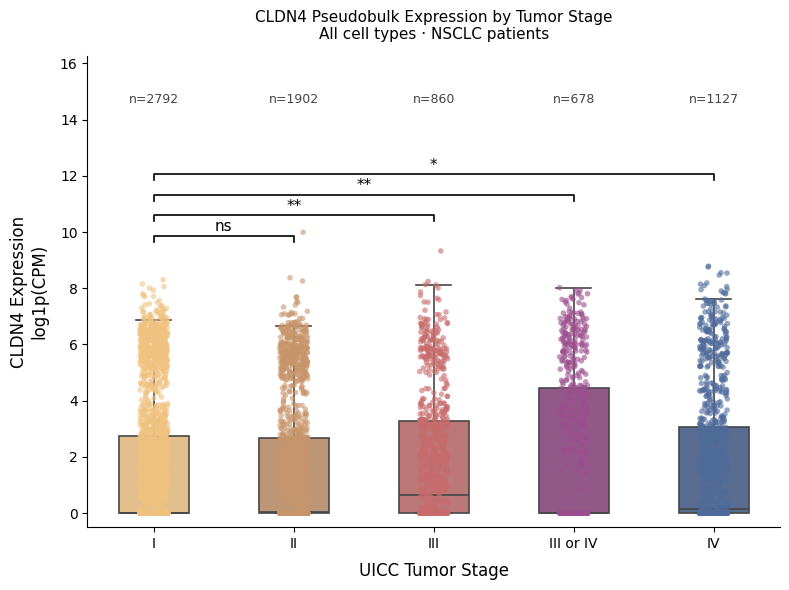

Saved: cldn4_by_stage_allcells.pdf / .png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 3 — CLDN4 BY TUMOR STAGE (ALL cell types)
# ══════════════════════════════════════════════════════════════════

# Filter: all cell types + known uicc_stage
df3 = ps_adata.obs[
    ps_adata.obs["uicc_stage"].notna()
].copy()

print("\nPlot 3 — unique uicc_stage labels:", df3["uicc_stage"].unique().tolist())

# Reuse same stage_order and palette from Plot 2
df3["uicc_stage"] = pd.Categorical(df3["uicc_stage"],
                                    categories=stage_order, ordered=True)
df3 = df3[df3["uicc_stage"].notna()].copy()

fig3, ax3 = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df3, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    width=0.5, linewidth=1.2, fliersize=0, ax=ax3,
)
sns.stripplot(
    data=df3, x="uicc_stage", y="CLDN4_expr",
    order=stage_order, palette=palette2,
    size=4, alpha=0.6, jitter=True, ax=ax3,
)

# n= annotations
ymin3, ymax3 = ax3.get_ylim()
for i, stage in enumerate(stage_order):
    n = (df3["uicc_stage"] == stage).sum()
    ax3.text(i, ymax3 * 1.38,
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

# Significance vs Stage I
print("\nPlot 3 significance (vs Stage I):")
add_significance(ax3, stage_order, "uicc_stage", "CLDN4_expr",
                 df3, ref_group=stage_order[0], ymax=ymax3)

ax3.set_ylim(ymin3, ymax3 * 1.55)
ax3.set_xlabel("UICC Tumor Stage", fontsize=12, labelpad=8)
ax3.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
ax3.set_title("CLDN4 Pseudobulk Expression by Tumor Stage\nAll cell types · NSCLC patients",
              fontsize=11, pad=12)
ax3.spines[["top", "right"]].set_visible(False)
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage_allcells.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "cldn4_by_stage_allcells.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cldn4_by_stage_allcells.pdf / .png")

In [ ]:
# Check exact labels
print(adata.obs["cell_type"].unique().tolist())

# Specifically search for epithelial and malignant
import pandas as pd
cell_types = adata.obs["cell_type"].unique().tolist()
epithelial = [c for c in cell_types if "epithelial" in c.lower()]
malignant  = [c for c in cell_types if "malignant" in c.lower() or "tumor" in c.lower() or "cancer" in c.lower()]

print("Epithelial:", epithelial)
print("Malignant:", malignant)

['non-classical monocyte', 'alveolar macrophage', 'endothelial cell of lymphatic vessel', 'macrophage', 'classical monocyte', 'malignant cell', 'CD8-positive, alpha-beta T cell', 'myeloid cell', 'natural killer cell', 'CD1c-positive myeloid dendritic cell', 'B cell', 'capillary endothelial cell', 'regulatory T cell', 'epithelial cell of lung', 'pulmonary alveolar type 1 cell', 'vein endothelial cell', 'CD4-positive, alpha-beta T cell', 'pulmonary artery endothelial cell', 'fibroblast of lung', 'plasma cell', 'smooth muscle cell', 'multiciliated epithelial cell', 'club cell', 'mesothelial cell', 'pulmonary alveolar type 2 cell', 'conventional dendritic cell', 'mast cell', 'stromal cell', 'plasmacytoid dendritic cell', 'dendritic cell', 'pericyte', 'bronchus fibroblast of lung', 'neutrophil']
Epithelial: ['epithelial cell of lung', 'multiciliated epithelial cell']
Malignant: ['malignant cell']


Subset: 127,560 cells
cell_type_plot
malignant cell             89243
epithelial_sub             34723
epithelial cell of lung     3594
Name: count, dtype: int64
origin
tumor_primary       75226
normal              38317
tumor_metastasis    14017
Name: count, dtype: int64


/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/ebrukocakaya/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.ma


Pseudobulk shape: (443, 17764)
                                                             cell_type_plot  \
Adams_Kaminski_2020_001C_epithelial cell of lung    epithelial cell of lung   
Adams_Kaminski_2020_001C_epithelial_sub                      epithelial_sub   
Adams_Kaminski_2020_002C_epithelial cell of lung    epithelial cell of lung   
Adams_Kaminski_2020_002C_epithelial_sub                      epithelial_sub   
Adams_Kaminski_2020_003C_epithelial_sub                      epithelial_sub   
Adams_Kaminski_2020_003C_epithelial cell of lung    epithelial cell of lung   
Adams_Kaminski_2020_022C-a_epithelial_sub                    epithelial_sub   
Adams_Kaminski_2020_022C-a_epithelial cell of lung  epithelial cell of lung   
Adams_Kaminski_2020_022C-b_epithelial_sub                    epithelial_sub   
Adams_Kaminski_2020_022C-b_epithelial cell of lung  epithelial cell of lung   

                                                    origin  uicc_stage  \
Adams_Kaminski_2020_001C

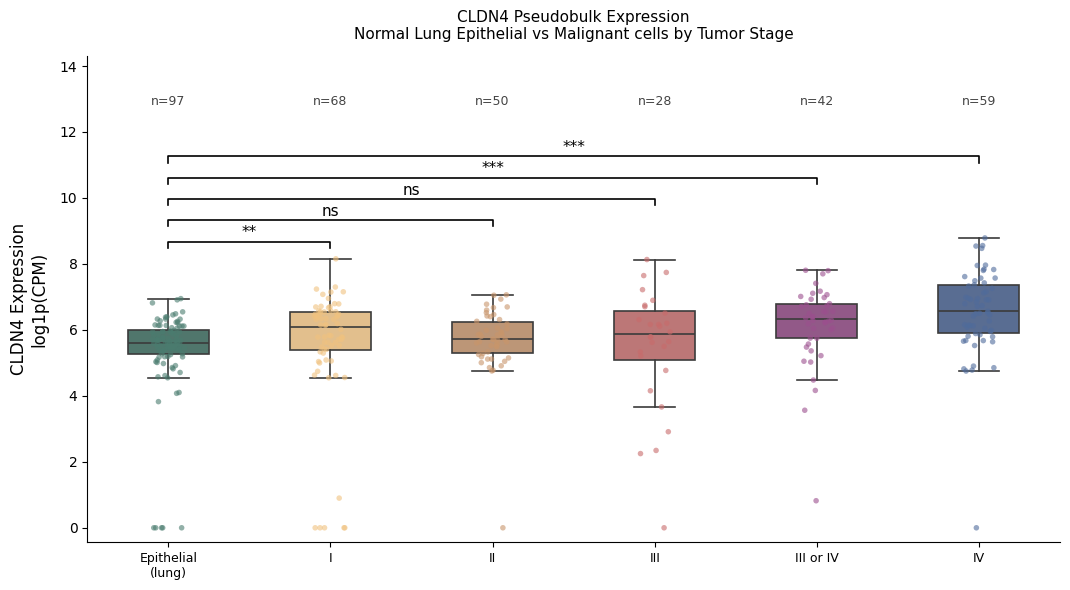

Saved: cldn4_epithelial_vs_stage.pdf / .png

CLDN4 Pseudobulk Expression
Normal Epithelial (lung + sub) vs Malignant cells by Tumor Stage — significance vs Epithelial
(lung):
  Epithelial
(lung) vs Epithelial
(sub): p=3.06e-01 ns
  Epithelial
(lung) vs I: p=2.79e-03 **
  Epithelial
(lung) vs II: p=1.31e-01 ns
  Epithelial
(lung) vs III: p=1.62e-01 ns
  Epithelial
(lung) vs III or IV: p=5.30e-06 ***
  Epithelial
(lung) vs IV: p=1.34e-10 ***


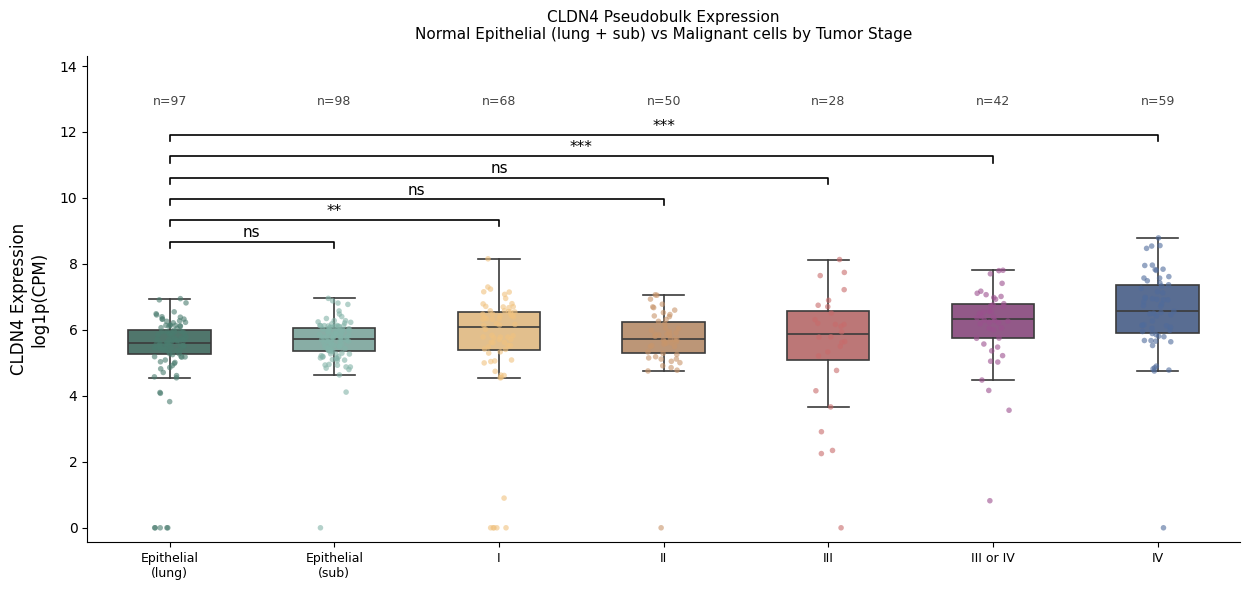

Saved: cldn4_epithelial_sub_vs_stage.pdf / .png


In [12]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import issparse

# ══════════════════════════════════════════════════════════════════════════════
# OUTPUT DIRECTORY
# ══════════════════════════════════════════════════════════════════════════════

#OUT_DIR = "/path/to/your/figures"   # !! change this !!
OUT_DIR= "/home/ebrukocakaya/"
os.makedirs(OUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def make_pseudobulk(adata, sample_colname, cell_type_colname, metacols):
    '''
    Pseudobulk by summing RAW counts per sample × cell_type.
    Uses adata.raw.X — required for valid CPM + log1p normalization.
    '''
    assert adata.raw is not None, "adata.raw is None — raw counts not stored!"
    raw_var  = pd.DataFrame(index=adata.raw.var_names)
    ps_list  = []

    for s in adata.obs[sample_colname].unique():
        adata_sub = adata[adata.obs[sample_colname] == s]
        for ct in adata_sub.obs[cell_type_colname].unique():
            adata_sub_ct = adata_sub[adata_sub.obs[cell_type_colname] == ct]
            X_sum = adata_sub_ct.raw.X.sum(axis=0)
            if issparse(X_sum):
                X_sum = X_sum.toarray()
            adata_rep                        = sc.AnnData(X=X_sum, var=raw_var)
            adata_rep.obs_names              = [f"{s}_{ct}"]
            adata_rep.obs[cell_type_colname] = ct
            adata_rep.obs[metacols]          = adata_sub_ct.obs[metacols].iloc[0].values
            ps_list.append(adata_rep)

    return sc.concat(ps_list)


def extract_gene(ps_adata, gene):
    '''Extract a single gene's expression into obs column.'''
    assert gene in ps_adata.var_names, \
        f"{gene} not found in var_names!"
    idx  = ps_adata.var_names.get_loc(gene)
    expr = ps_adata.X[:, idx]
    if issparse(expr):
        expr = expr.toarray().flatten()
    ps_adata.obs[f"{gene}_expr"] = np.array(expr).flatten()
    return ps_adata


def pval_to_stars(p):
    if p < 0.001:   return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "ns"


def add_significance(ax, group_order, group_col, expr_col, df,
                     ref_group, ymax, step_size=0.07):
    '''Significance brackets vs ref_group using Mann-Whitney U.'''
    ref_data    = df[df[group_col] == ref_group][expr_col].dropna().values
    ref_x       = group_order.index(ref_group)
    comparisons = [g for g in group_order if g != ref_group]

    for step, comp in enumerate(comparisons):
        comp_data = df[df[group_col] == comp][expr_col].dropna().values
        _, p      = stats.mannwhitneyu(ref_data, comp_data,
                                       alternative="two-sided")
        stars     = pval_to_stars(p)
        comp_x    = group_order.index(comp)
        y_line    = ymax * (0.92 + step * step_size)

        ax.plot([ref_x, ref_x, comp_x, comp_x],
                [y_line, y_line + ymax*0.02,
                 y_line + ymax*0.02, y_line],
                lw=1.2, color="black")
        ax.text((ref_x + comp_x) / 2, y_line + ymax*0.025,
                stars, ha="center", va="bottom", fontsize=11)
        print(f"  {ref_group} vs {comp}: p={p:.2e} {stars}")


# ══════════════════════════════════════════════════════════════════════════════
# SETUP — var_names to gene symbols
# ══════════════════════════════════════════════════════════════════════════════

if "CLDN4" not in adata.var_names:
    adata.var_names = adata.var["feature_name"]
    adata.var_names_make_unique()

if "CLDN4" not in adata.raw.var_names:
    raw_adata = adata.raw.to_adata()
    raw_adata.var_names = raw_adata.var["feature_name"]
    raw_adata.var_names_make_unique()
    adata.raw = raw_adata

# ══════════════════════════════════════════════════════════════════════════════
# CELL TYPE DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

LUNG_EPITHELIAL = "epithelial cell of lung"

EPITHELIAL_SUB  = [
    "multiciliated epithelial cell",
    "pulmonary alveolar type 1 cell",
    "pulmonary alveolar type 2 cell",
    "club cell",
]

MALIGNANT       = "malignant cell"

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — SUBSET
# Normal origin  → epithelial cell of lung + epithelial_sub
# Tumor origin   → malignant cell only (exclude normal/normal_adjacent)
# ══════════════════════════════════════════════════════════════════════════════

# Epithelial cells from normal tissue only
mask_epi = (
    adata.obs["cell_type"].isin([LUNG_EPITHELIAL] + EPITHELIAL_SUB) &
    (adata.obs["origin"] == "normal")
)

# Malignant cells from tumor tissue only
mask_mal = (
    (adata.obs["cell_type"] == MALIGNANT) &
    (adata.obs["origin"].isin(["tumor_primary", "tumor_metastasis"]))
)

adata_sub = adata[mask_epi | mask_mal].copy()

# Remap cell_type: merge epithelial_sub into one label
adata_sub.obs["cell_type_plot"] = adata_sub.obs["cell_type"].apply(
    lambda x: "epithelial_sub" if x in EPITHELIAL_SUB else x
)

print(f"Subset: {adata_sub.n_obs:,} cells")
print(adata_sub.obs["cell_type_plot"].value_counts())
print(adata_sub.obs["origin"].value_counts())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — ONE PSEUDOBULK per sample × cell_type_plot
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = make_pseudobulk(
    adata_sub,
    sample_colname    = "sample",
    cell_type_colname = "cell_type_plot",
    metacols          = ["origin", "uicc_stage"]
)
print(f"\nPseudobulk shape: {ps_adata.shape}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — NORMALIZE
# ══════════════════════════════════════════════════════════════════════════════

sc.pp.normalize_total(ps_adata, target_sum=1e6)  # CPM
sc.pp.log1p(ps_adata)                            # log1p(CPM)


#save pseudobulk adata:

ps_adata.write_h5ad(os.path.join(OUT_DIR, "20260317_cldn4_pseudobulk_epithelial.h5ad"))


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CLDN4
# ══════════════════════════════════════════════════════════════════════════════

ps_adata = extract_gene(ps_adata, "CLDN4")
print(ps_adata.obs[["cell_type_plot", "origin", "uicc_stage", "CLDN4_expr"]].head(10))

# ══════════════════════════════════════════════════════════════════════════════
# STAGE ORDER
# ══════════════════════════════════════════════════════════════════════════════

print("\nUnique uicc_stage labels:", ps_adata.obs["uicc_stage"].unique().tolist())

stage_order  = ["I", "II", "III", "III or IV", "IV"]
stage_order  = [s for s in stage_order
                if s in ps_adata.obs["uicc_stage"].values]

stage_colors = {
    "I"        : "#f0c27f",
    "II"       : "#c8956b",
    "III"      : "#c86b6b",
    "III or IV": "#9b4f8e",
    "IV"       : "#4f6b9b",
}

# Reference group colors
REF_COLOR_LUNG = "#4a7c6f"   # dark teal — epithelial cell of lung
REF_COLOR_SUB  = "#82b3a8"   # light teal — epithelial_sub


def make_plot(ps_obs, group_order, palette, title, fname):
    '''Generic boxplot + stripplot with n= and significance brackets.'''

    df = ps_obs[ps_obs["group"].isin(group_order)].copy()
    df["group"] = pd.Categorical(df["group"],
                                  categories=group_order, ordered=True)
    df = df[df["group"].notna()].copy()

    fig, ax = plt.subplots(figsize=(len(group_order) * 1.8, 6))

    sns.boxplot(
        data=df, x="group", y="CLDN4_expr",
        order=group_order, palette=palette,
        width=0.5, linewidth=1.2, fliersize=0, ax=ax,
    )
    sns.stripplot(
        data=df, x="group", y="CLDN4_expr",
        order=group_order, palette=palette,
        size=4, alpha=0.6, jitter=True, ax=ax,
    )

    ymin, ymax = ax.get_ylim()

    # n= above brackets
    for i, grp in enumerate(group_order):
        n = (df["group"] == grp).sum()
        ax.text(i, ymax * 1.38, f"n={n}",
                ha="center", va="bottom", fontsize=9, color="#444444")

    # Significance vs first group (reference)
    print(f"\n{title} — significance vs {group_order[0]}:")
    add_significance(ax, group_order, "group", "CLDN4_expr",
                     df, ref_group=group_order[0], ymax=ymax)

    ax.set_ylim(ymin, ymax * 1.55)
    ax.set_xlabel(None)
    ax.set_ylabel("CLDN4 Expression\nlog1p(CPM)", fontsize=12, labelpad=8)
    ax.set_title(title, fontsize=11, pad=12)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{fname}.pdf"),
                dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(OUT_DIR, f"{fname}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}.pdf / .png")


# ══════════════════════════════════════════════════════════════════════════════
# PREPARE SHARED obs DATAFRAME
# Add a "group" column:
#   - epithelial cell of lung → "Epithelial\n(lung)"
#   - epithelial_sub          → "Epithelial\n(sub)"
#   - malignant cell          → uicc_stage label
# ══════════════════════════════════════════════════════════════════════════════

def build_plot_df(ps_adata, include_sub=False):
    obs = ps_adata.obs.copy()

    # Assign group label
    def assign_group(row):
        if row["cell_type_plot"] == LUNG_EPITHELIAL:
            return "Epithelial\n(lung)"
        elif row["cell_type_plot"] == "epithelial_sub":
            return "Epithelial\n(sub)"
        elif row["cell_type_plot"] == MALIGNANT:
            return row["uicc_stage"]
        return np.nan

    obs["group"] = obs.apply(assign_group, axis=1)
    obs = obs[obs["group"].notna()].copy()

    if not include_sub:
        obs = obs[obs["group"] != "Epithelial\n(sub)"].copy()

    return obs


# ══════════════════════════════════════════════════════════════════════════════
# PLOT A — Epithelial cell of lung + Malignant by stage
# ══════════════════════════════════════════════════════════════════════════════

df_a = build_plot_df(ps_adata, include_sub=False)

group_order_a = ["Epithelial\n(lung)"] + stage_order
palette_a     = [REF_COLOR_LUNG] + [stage_colors.get(s, "#888888")
                                     for s in stage_order]

make_plot(
    df_a, group_order_a, palette_a,
    title = "CLDN4 Pseudobulk Expression\nNormal Lung Epithelial vs Malignant cells by Tumor Stage",
    fname = "cldn4_epithelial_vs_stage"
)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT B — Epithelial cell of lung + Epithelial sub + Malignant by stage
# ══════════════════════════════════════════════════════════════════════════════

df_b = build_plot_df(ps_adata, include_sub=True)

group_order_b = ["Epithelial\n(lung)", "Epithelial\n(sub)"] + stage_order
palette_b     = [REF_COLOR_LUNG, REF_COLOR_SUB] + \
                [stage_colors.get(s, "#888888") for s in stage_order]

make_plot(
    df_b, group_order_b, palette_b,
    title = "CLDN4 Pseudobulk Expression\nNormal Epithelial (lung + sub) vs Malignant cells by Tumor Stage",
    fname = "cldn4_epithelial_sub_vs_stage"
)


CLDN4 Pseudobulk Expression
Normal Epithelial (sub) vs Malignant cells by Tumor Stage — significance vs Epithelial
(sub):
  Epithelial
(sub) vs Epithelial
(lung): p=3.06e-01 ns
  Epithelial
(sub) vs I: p=2.03e-02 *
  Epithelial
(sub) vs II: p=5.73e-01 ns
  Epithelial
(sub) vs III: p=3.45e-01 ns
  Epithelial
(sub) vs III or IV: p=2.32e-05 ***
  Epithelial
(sub) vs IV: p=2.09e-09 ***


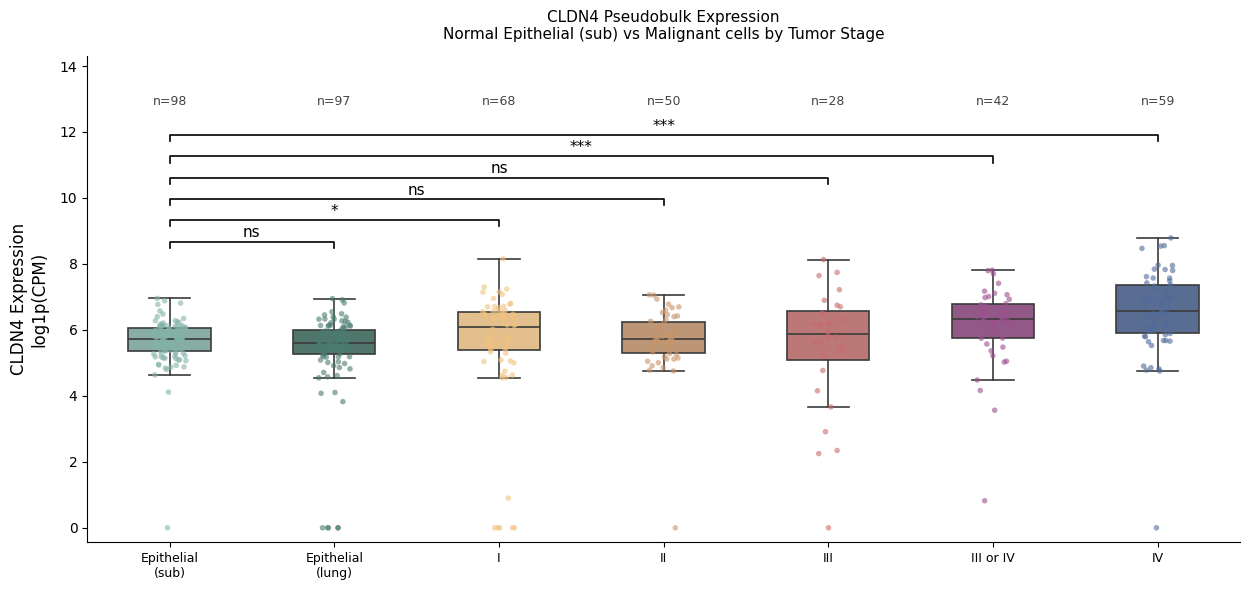

Saved: cldn4_epithelial_sub_ref_vs_stage.pdf / .png


In [16]:
# ══════════════════════════════════════════════════════════════════
# PLOT C — Epithelial (sub) as reference + Epithelial (lung) + Malignant by stage
# ══════════════════════════════════════════════════════════════════

df_c = build_plot_df(ps_adata, include_sub=True)

group_order_c = ["Epithelial\n(sub)", "Epithelial\n(lung)"] + stage_order
palette_c     = [REF_COLOR_SUB, REF_COLOR_LUNG] + \
                [stage_colors.get(s, "#888888") for s in stage_order]

make_plot(
    df_c, group_order_c, palette_c,
    title = "CLDN4 Pseudobulk Expression\nNormal Epithelial (sub) vs Malignant cells by Tumor Stage",
    fname = "cldn4_epithelial_sub_ref_vs_stage"
)

In [18]:
# Compare sample counts with and without uicc_stage filter
print("All malignant tumor samples:")
mal_mask = (
    (adata.obs["cell_type"] == "malignant cell") &
    (adata.obs["origin"].isin(["tumor_primary", "tumor_metastasis"]))
)
print(adata.obs[mal_mask]["sample"].nunique())

print("\nMalignant tumor samples WITH known uicc_stage:")
mal_mask_stage = mal_mask & adata.obs["uicc_stage"].notna()
print(adata.obs[mal_mask_stage]["sample"].nunique())

print("\nSamples lost due to missing uicc_stage:")
print(adata.obs[mal_mask & ~mal_mask_stage]["sample"].nunique())

All malignant tumor samples:
248

Malignant tumor samples WITH known uicc_stage:
247

Samples lost due to missing uicc_stage:
1


In [20]:
# How many pseudobulk profiles do we actually have for malignant cells?
mal_ps = ps_adata.obs[ps_adata.obs["cell_type_plot"] == "malignant cell"]
print("Total malignant pseudobulk profiles:", len(mal_ps))
print("\nBy uicc_stage:")
print(mal_ps["uicc_stage"].value_counts(dropna=False))

# Compare with last week
print("\nLast week's pseudobulk had:")
print("Stage I: 107, II: 77, III: 38, III or IV: 42, IV: 61")
print("Total:", 107+77+38+42+61)

Total malignant pseudobulk profiles: 248

By uicc_stage:
uicc_stage
I             68
IV            59
II            50
III or IV     42
III           28
NaN            1
non-cancer     0
Name: count, dtype: int64

Last week's pseudobulk had:
Stage I: 107, II: 77, III: 38, III or IV: 42, IV: 61
Total: 325


In [22]:
# How many malignant cells per origin in original adata
print("Malignant cells by origin:")
print(adata.obs[adata.obs["cell_type"] == "malignant cell"]["origin"].value_counts(dropna=False))

# How many unique samples per origin for malignant cells
print("\nUnique samples with malignant cells per origin:")
print(adata.obs[adata.obs["cell_type"] == "malignant cell"].groupby("origin")["sample"].nunique())



Malignant cells by origin:
origin
tumor_primary       75226
tumor_metastasis    14017
normal_adjacent      1435
normal                847
nan                     3
Name: count, dtype: int64

Unique samples with malignant cells per origin:
origin
nan                   2
normal               90
normal_adjacent      94
tumor_metastasis     48
tumor_primary       200
Name: sample, dtype: int64


In [ ]:
#ps_adata_luca=sc.read_h5ad("/home/ebrukocakaya/20260317_cldn4_pseudobulk_epithelial.h5ad")
ps_adata

AnnData object with n_obs × n_vars = 443 × 17764
    obs: 'cell_type_plot', 'origin', 'uicc_stage', 'CLDN4_expr'
    uns: 'log1p'

In [10]:
ps_adata.write_h5ad(os.path.join(OUT_DIR, "20260317_cldn4_pseudobulk_epithelial.h5ad"))



CLDN4 Expression
Normal Lung Epithelial vs Malignant cells by Tumor Stage — significance vs Epithelial
(normal lung):
  Epithelial
(normal lung) vs I: p=2.86e-03 **
  Epithelial
(normal lung) vs II: p=2.55e-01 ns
  Epithelial
(normal lung) vs III: p=2.13e-01 ns
  Epithelial
(normal lung) vs III or IV: p=1.82e-06 ***
  Epithelial
(normal lung) vs IV: p=5.25e-12 ***


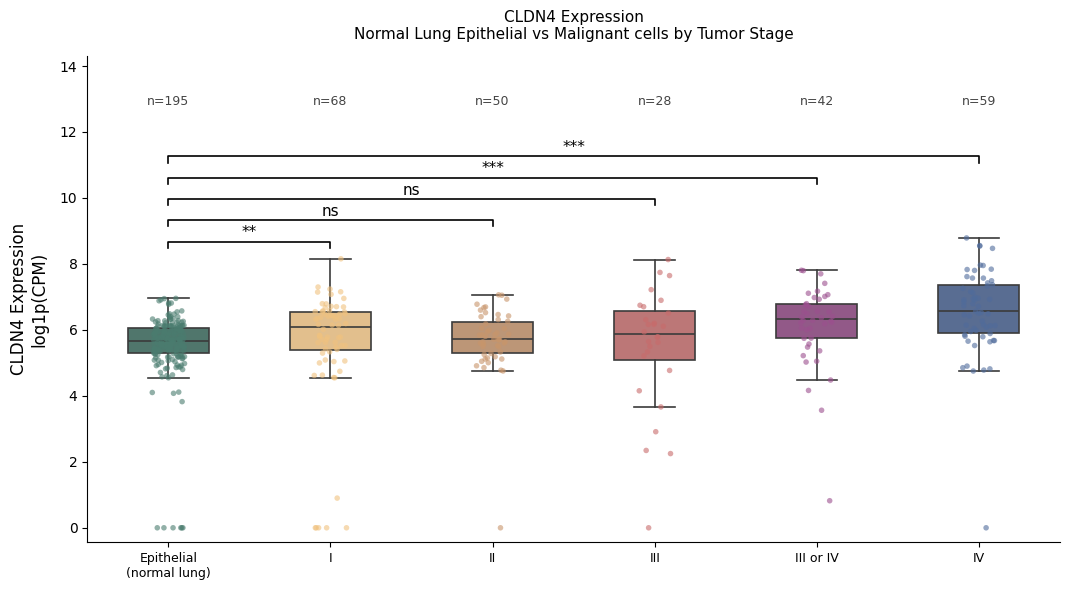

Saved: cldn4_epithelial_merged_vs_stage.pdf / .png


In [14]:
def build_plot_df(ps_adata, include_sub=True):
    obs = ps_adata.obs.copy()

    def assign_group(row):
        if row["cell_type_plot"] in [LUNG_EPITHELIAL, "epithelial_sub"]:
            return "Epithelial\n(normal lung)"  # ← both merged into one
        elif row["cell_type_plot"] == MALIGNANT:
            return row["uicc_stage"]
        return np.nan

    obs["group"] = obs.apply(assign_group, axis=1)
    obs = obs[obs["group"].notna()].copy()
    return obs

# ── Single merged plot ────────────────────────────────────────────
df_merged = build_plot_df(ps_adata)

group_order_merged = ["Epithelial\n(normal lung)"] + stage_order
palette_merged     = [REF_COLOR_LUNG] + [stage_colors.get(s, "#888888")
                                          for s in stage_order]

make_plot(
    df_merged, group_order_merged, palette_merged,
    title = "CLDN4 Expression\nNormal Lung Epithelial vs Malignant cells by Tumor Stage",
    fname = "cldn4_epithelial_merged_vs_stage"
)


CLDN4 Pseudobulk Expression
Normal Lung Epithelial vs Malignant cells by Tumor Stage — significance vs Epithelial
(normal lung):
  Epithelial
(normal lung) vs I: p=2.86e-03 **
  Epithelial
(normal lung) vs II: p=2.55e-01 ns
  Epithelial
(normal lung) vs III: p=2.13e-01 ns
  Epithelial
(normal lung) vs III or IV: p=1.82e-06 ***
  Epithelial
(normal lung) vs IV: p=5.25e-12 ***


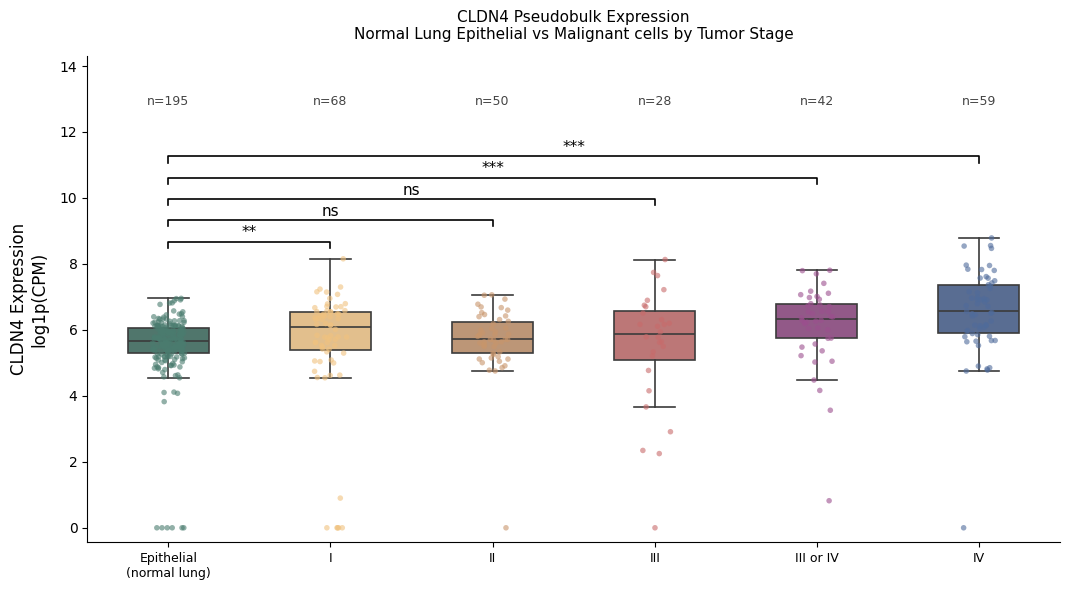

Saved: /home/ebrukocakaya/cldn4_epithelial_merged_vs_stage.pdf / .png


In [17]:
PLOT_OUT = "/home/ebrukocakaya/"

make_plot(
    df_merged, group_order_merged, palette_merged,
    title = "CLDN4 Pseudobulk Expression\nNormal Lung Epithelial vs Malignant cells by Tumor Stage",
    fname = os.path.join(PLOT_OUT, "cldn4_epithelial_merged_vs_stage")
)